# Notebook 10 — Excited States: CIS, UHF, EOM-CCSD, TD-DFT

**MOLEKUL | Phases 13, 16, 15, 17**

---

Ground-state quantum chemistry is only the beginning. Spectroscopy, photochemistry,
and light-harvesting all require knowledge of **excited states** — the higher-energy
solutions of the electronic Schrödinger equation.

MOLEKUL implements four complementary approaches:

| Method | Theory | Open-shell | Accuracy |
|--------|--------|-----------|----------|
| UHF | Unrestricted HF | ✓ | Ground state only, spin-contaminated |
| CIS | Configuration Interaction Singles | ✗ | Qualitative, cheap |
| EOM-CCSD | Equation-of-Motion CCSD | ✗ | High accuracy, $\mathcal{O}(N^6)$ |
| TD-DFT/TDA | Linear-response DFT (Tamm-Dancoff) | ✗ | Affordable, often good |

**What you will learn:**
1. Spin contamination in UHF and the $\langle S^2\rangle$ diagnostic.
2. CIS: the simplest excited-state theory and its limitations.
3. TD-DFT (TDA): the linear response of the KS density to a perturbation.
4. EOM-CCSD: the gold standard for excitation energies.

In [1]:
# --- Make the MOLEKUL package importable -------------------------------
# Best practice: install once from the repo root with
#     pip install -e ".[notebooks]"
# The fallback below locates the in-repo src/ automatically, so the
# notebook also runs from a fresh clone that has not been installed yet,
# regardless of which directory Jupyter was started from.
try:
    import molekul  # noqa: F401
except ModuleNotFoundError:
    import sys, pathlib
    for _p in (pathlib.Path.cwd(), *pathlib.Path.cwd().parents):
        if (_p / "src" / "molekul").is_dir():
            sys.path.insert(0, str(_p / "src"))
            break
    import molekul  # noqa: F401
# -----------------------------------------------------------------------

import numpy as np
import matplotlib.pyplot as plt

from molekul.atoms import Atom
from molekul.molecule import Molecule
from molekul.basis_sto3g import STO3G
from molekul.basis_631gstar import G631Star
from molekul.rhf import rhf_scf
from molekul.uhf import uhf_scf
from molekul.cis import cis_excitations
from molekul.eom_ccsd import eom_ccsd_ee
from molekul.tddft import tddft_tda
from molekul.constants import HARTREE_TO_EV, HARTREE_TO_KCAL_MOL

# Water: closed-shell reference for excited states
h2o = Molecule(
    atoms=[
        Atom.from_angstrom("O",  0.0000,  0.0000,  0.1173),
        Atom.from_angstrom("H",  0.7572,  0.0000, -0.4692),
        Atom.from_angstrom("H", -0.7572,  0.0000, -0.4692),
    ],
    name="water",
)

# OH radical: open-shell doublet for UHF
oh = Molecule(
    atoms=[
        Atom.from_angstrom("O", 0.0, 0.0, 0.0),
        Atom.from_angstrom("H", 0.0, 0.0, 0.9697),
    ],
    multiplicity=2,
    name="OH radical",
)
print("Ready.")

Ready.


## 1. Unrestricted Hartree-Fock (UHF)

RHF forces $\psi_i^\alpha = \psi_i^\beta$ (same spatial orbital for both spins).
For open-shell systems (radicals, triplets) this constraint is wrong.

**UHF** relaxes this: separate spatial orbitals for $\alpha$ and $\beta$ electrons.

The UHF energy is:
$$E_{\text{UHF}} = \frac{1}{2}\text{tr}[(P^\alpha + P^\beta)H_{\text{core}}]
+ \frac{1}{2}\text{tr}[P^\alpha F^\alpha + P^\beta F^\beta] + E_{\text{nuc}}$$

**Spin contamination:** UHF wavefunctions are not exact eigenstates of $\hat{S}^2$.
For a pure doublet, $\langle\hat{S}^2\rangle = S(S+1) = 0.75$.
UHF gives $\langle\hat{S}^2\rangle \geq 0.75$, with the excess measuring contamination
by higher spin states. $\langle\hat{S}^2\rangle > 1.0$ for a doublet signals severe contamination.

In [2]:
basis = STO3G

# UHF for OH radical (doublet)
uhf_res = uhf_scf(oh, basis, verbose=True)

print(f"\nUHF energy:   {uhf_res.energy_total:.6f} Ha")
print(f"Converged:    {uhf_res.converged} in {uhf_res.n_iter} iterations")
print(f"n_alpha:      {uhf_res.n_occ_a}, n_beta: {uhf_res.n_occ_b}")
print(f"<S²>:         {uhf_res.S2:.6f}  (ideal doublet: 0.75)")
print(f"Spin contamination: {uhf_res.S2 - 0.75:.4f}")


Iter     E_total (Hartree)             dE         dP_max  DIIS
------------------------------------------------------------
   1          4.3656986614   4.365699e+00   1.218953e+00     -
   2        -73.6079814982  -7.797368e+01   0.000000e+00     2
   3        -73.6079814982   0.000000e+00   5.974646e-01     3
   4        -74.3489587721  -7.409773e-01   7.607421e-02     4
   5        -74.3623490586  -1.339029e-02   1.060357e-02     5
   6        -74.3625895648  -2.405062e-04   3.304818e-03     6
   7        -74.3626172984  -2.773368e-05   2.004893e-03     7
   8        -74.3626279545  -1.065605e-05   1.394209e-03     8
   9        -74.3626329211  -4.966579e-06   9.772593e-04     8
  10        -74.3626353043  -2.383193e-06   2.244550e-03     8
  11        -74.3626375294  -2.225165e-06   1.980068e-07     8
  12        -74.3626375294  -2.842171e-14   6.442111e-09     8
  13        -74.3626375294   2.842171e-14   1.967795e-10     8

UHF CONVERGED in 13 iterations
  E_nuclear    =       4

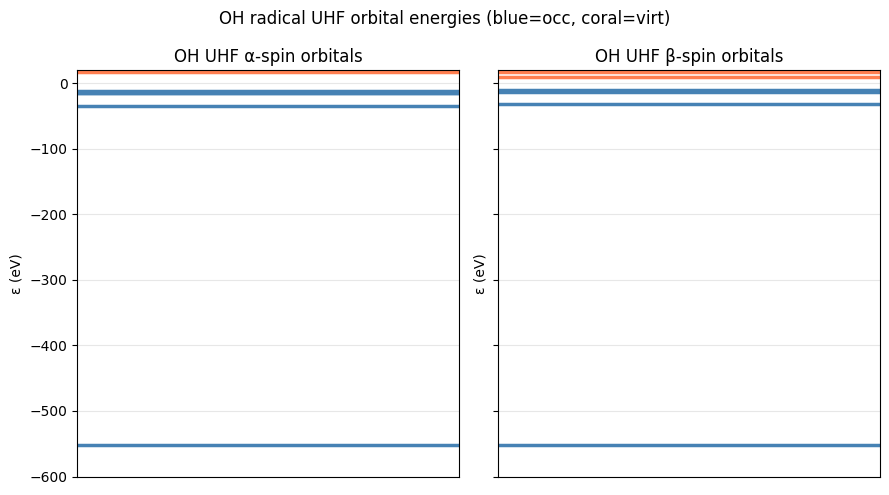

In [3]:
# Visualise the α and β orbital energy levels
n_a = uhf_res.n_occ_a
n_b = uhf_res.n_occ_b

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(9, 5), sharey=True)
for ax, eps, n_occ, label in [
        (ax1, uhf_res.epsa*HARTREE_TO_EV, n_a, "α"),
        (ax2, uhf_res.epsb*HARTREE_TO_EV, n_b, "β"),
]:
    for i, e in enumerate(eps):
        color = "steelblue" if i < n_occ else "coral"
        ax.axhline(e, lw=2.5, color=color)
    ax.set_title(f"OH UHF {label}-spin orbitals")
    ax.set_ylabel("ε (eV)")
    ax.set_xticks([])
    ax.set_ylim(-600, 20)
    ax.grid(True, alpha=0.3, axis="y")

plt.suptitle("OH radical UHF orbital energies (blue=occ, coral=virt)")
plt.tight_layout()
plt.show()

## 2. Configuration Interaction Singles (CIS)

CIS expresses each excited state as a linear combination of all singly-excited determinants:
$$|\Psi_K\rangle = \sum_{ia} t_{ia}^K \hat{a}_a^\dagger\hat{a}_i|\Phi_0\rangle$$

The CIS Hamiltonian in the $(ia)$ basis (singlets, using spatial orbitals):
$$A_{ia,jb} = \delta_{ij}\delta_{ab}(\varepsilon_a - \varepsilon_i) + 2(ia|jb) - (ij|ab)$$

Excitation energies $\Delta E_K$ are the eigenvalues of $\mathbf{A}$.

**Limitations:**
- CIS includes no correlation in the excited state (only in the reference).
- Excitation energies are systematically overestimated by ~1 eV.
- Doubly-excited states are completely missed.

**Advantage:** Very cheap — scales as $\mathcal{O}(N^4)$ like HF.

In [4]:
basis = STO3G
rhf_res = rhf_scf(h2o, basis)
cis_res = cis_excitations(h2o, basis, rhf_res, n_states=5)

print('CIS excited states of H₂O/STO-3G:')
print(f"{'State':>6}  {'dE (Ha)':>10}  {'dE (eV)':>10}  {'f (osc)':>10}")
print('-' * 42)
for i in range(cis_res.n_states):
    de_ha = cis_res.excitation_energies[i]
    de_ev = cis_res.excitation_energies_ev[i]
    f_osc = cis_res.oscillator_strengths[i]
    print(f'{i+1:>6}  {de_ha:>10.4f}  {de_ev:>10.4f}  {f_osc:>10.4f}')



  CIS: n_occ=5, n_virt=2, dim=10
  Building MO ERIs …


  Building CIS matrix …
  Diagonalising …

  State       ΔE (Ha)     ΔE (eV)           f
  ----------------------------------------------
      1      0.484640     13.1877    0.003542
      2      0.556551     15.1445    0.000000
      3      0.616312     16.7707    0.077219
      4      0.704972     19.1833    0.059865
      5      0.810827     22.0637    1.166942
CIS excited states of H₂O/STO-3G:
 State     dE (Ha)     dE (eV)     f (osc)
------------------------------------------
     1      0.4846     13.1877      0.0035
     2      0.5566     15.1445      0.0000
     3      0.6163     16.7707      0.0772
     4      0.7050     19.1833      0.0599
     5      0.8108     22.0637      1.1669


## 3. TD-DFT in the Tamm-Dancoff Approximation

**Time-dependent DFT** (Runge-Gross 1984) extends DFT to excited states via the
linear response of the density to a time-dependent perturbation.

In the **Tamm-Dancoff Approximation** (TDA), the excitation energies are eigenvalues of:
$$\mathbf{A}\mathbf{X} = \omega\mathbf{X}$$

where the TDA matrix is:
$$A_{ia,jb} = \delta_{ij}\delta_{ab}(\varepsilon_a - \varepsilon_i)
+ (ia|jb) - (ia|f_{xc}|jb)$$

The XC kernel $(ia|f_{xc}|jb) = \int\phi_i\phi_a\,f_{xc}(\mathbf{r},\mathbf{r}')\,\phi_j\phi_b\,d^3rd^3r'$
is approximated in the adiabatic local density approximation:
$$f_{xc}^{\text{ALDA}}(\mathbf{r},\mathbf{r}') = \frac{\partial^2 E_{xc}}{\partial\rho^2}\bigg|_{\rho_0(\mathbf{r})}\delta(\mathbf{r}-\mathbf{r}')$$

MOLEKUL evaluates this numerically on the same Becke grid used for the KS calculation.

In [5]:
# TD-DFT/TDA: pass functional string 'lda', not the KS result
print('Running TD-DFT/TDA (LDA)...')
tddft_res = tddft_tda(h2o, basis, 'lda', n_states=5)

print('TD-DFT/TDA (LDA) excited states of H₂O/STO-3G:')
print(f"{'State':>6}  {'dE (Ha)':>10}  {'dE (eV)':>10}  {'f (osc)':>10}")
print('-' * 42)
for i in range(tddft_res.n_states):
    de_ha = tddft_res.excitation_energies[i]
    de_ev = tddft_res.excitation_eV[i]
    f_osc = tddft_res.oscillator_strengths[i]
    print(f'{i+1:>6}  {de_ha:>10.4f}  {de_ev:>10.4f}  {f_osc:>10.4f}')


Running TD-DFT/TDA (LDA)...


TD-DFT/TDA (LDA) excited states of H₂O/STO-3G:
 State     dE (Ha)     dE (eV)     f (osc)
------------------------------------------
     1      0.4221     11.4856      0.0026
     2      0.5065     13.7838      0.0000
     3      0.5196     14.1379      0.0742
     4      0.6522     17.7476      0.0669
     5      0.8088     22.0089      1.1033


## 4. EOM-CCSD: the gold standard for excitation energies

Equation-of-Motion CCSD (EOM-CCSD, Stanton & Bartlett 1993) applies a linear excitation
operator $\hat{R}$ to the CCSD ground state:

$$|\Psi_K\rangle = \hat{R}_K e^{\hat{T}}|\Phi_0\rangle$$

The excitation energies $\omega_K$ satisfy:
$$\bar{H}\mathbf{R}_K = \omega_K\mathbf{R}_K$$

where $\bar{H} = e^{-\hat{T}}\hat{H}e^{\hat{T}}$.

EOM-CCSD:
- Includes correlation in both ground and excited states.
- Typically accurate to 0.1–0.3 eV for valence excitations.
- Scales as $\mathcal{O}(N^6)$ — same as CCSD.
- Correctly describes doubly-excited states (unlike CIS/TD-DFT).

MOLEKUL implements EOM-EE-CCSD (excitation energies) using a singlet filter
($\langle S^2\rangle \approx 0$) on spin-orbital states.

In [6]:
# EOM-CCSD takes the RHF result (runs CCSD internally)
print('Running EOM-CCSD...')
eom_res = eom_ccsd_ee(h2o, basis, rhf_res, n_states=5)

print('EOM-CCSD excited states of H₂O/STO-3G:')
print(f"{'State':>6}  {'dE (Ha)':>10}  {'dE (eV)':>10}")
print('-' * 32)
for i in range(len(eom_res.excitation_energies)):
    print(f'{i+1:>6}  {eom_res.excitation_energies[i]:>10.4f}  {eom_res.excitation_eV[i]:>10.4f}')


Running EOM-CCSD...


EOM-CCSD excited states of H₂O/STO-3G:
 State     dE (Ha)     dE (eV)
--------------------------------
     1      0.4567     12.4267
     2      0.5414     14.7318
     3      0.5985     16.2857
     4      0.6989     19.0171
     5      0.8267     22.4958


## 5. Comparison of methods

Let us collect the first excited-state energy from each method and compare.

First singlet excitation energy (eV):
  CIS            : 13.188 eV
  TD-DFT/LDA     : 11.486 eV
  EOM-CCSD       : 12.427 eV


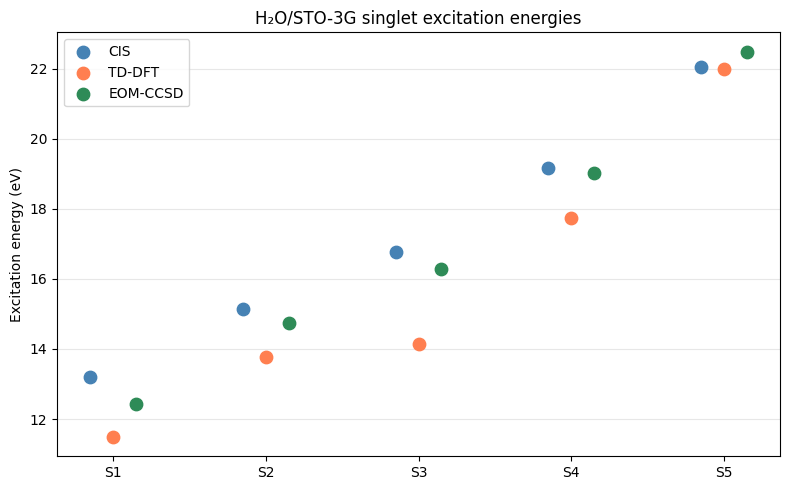

In [7]:
methods = {
    'CIS': cis_res.excitation_energies_ev[0],
    'TD-DFT/LDA': tddft_res.excitation_eV[0],
    'EOM-CCSD': eom_res.excitation_eV[0],
}

print('First singlet excitation energy (eV):')
for method, e in methods.items():
    print(f'  {method:15s}: {e:.3f} eV')

fig, ax = plt.subplots(figsize=(8, 5))
colors = ['steelblue', 'coral', 'seagreen']
n_states = min(cis_res.n_states, tddft_res.n_states, len(eom_res.excitation_energies))
x = np.arange(n_states)

for i, (method, color) in enumerate(zip(['CIS', 'TD-DFT', 'EOM-CCSD'], colors)):
    if method == 'CIS':
        vals = cis_res.excitation_energies_ev[:n_states]
    elif method == 'TD-DFT':
        vals = tddft_res.excitation_eV[:n_states]
    else:
        vals = eom_res.excitation_eV[:n_states]
    ax.scatter(x + i*0.15 - 0.15, vals, label=method, color=color, s=80, zorder=5)

ax.set_xticks(x)
ax.set_xticklabels([f'S{i+1}' for i in range(n_states)])
ax.set_ylabel('Excitation energy (eV)')
ax.set_title('H\u2082O/STO-3G singlet excitation energies')
ax.legend(); ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout(); plt.show()


---

## Exercises

**1.** Compute UHF for H₂O with charge=+1 (water cation, doublet).
What is $\langle S^2\rangle$? Is the spin contamination larger or smaller than for OH?

**2.** CIS excitation energies are systematically too high. By how many eV is the first
CIS excited state of H₂O overestimated compared to EOM-CCSD?

**3.** The oscillator strength $f = 0$ means the transition is optically dark (forbidden).
Which CIS excited states of H₂O are dark? What symmetry argument explains this?

**4.** For EOM-CCSD, the quality of excitation energies depends on the basis set.
How do the first three EOM-CCSD excitation energies change between STO-3G and 6-31G*?

**5.** (Advanced) The OH radical has an unpaired electron. Run UHF/STO-3G and compare
the SOMO (singly occupied MO) energy to the HOMO of the corresponding closed-shell
H₂O cation (RHF). What is the ionisation energy of the radical according to Koopmans'?

---

## Summary

| Method | Key feature | Scaling | Accuracy |
|--------|------------|---------|----------|
| UHF | Separate α/β orbitals; no spin symmetry | $\mathcal{O}(N^4)$ | Qualitative; spin-contaminated |
| CIS | Linear CI of single excitations | $\mathcal{O}(N^4)$ | ~1 eV too high; no doubles |
| TD-DFT/TDA | Linear response of KS density | $\mathcal{O}(N^4)$ | ~0.3–0.5 eV; charge-transfer problem |
| EOM-CCSD | Linear excitation on CCSD reference | $\mathcal{O}(N^6)$ | ~0.1–0.3 eV; handles doubles |

**T1 diagnostic analog:** For excited states, large EOM residuals or high CIS amplitudes
on a single $(i\to a)$ pair signal a "clean" single excitation.

The choice of excited-state method depends on balance between accuracy and cost —
the same trade-off as in ground-state correlation methods.